In [1]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused

NAME = '01102024-benchmark-resnet50_from_scratch-v4_10m'

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('../../../datasets/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter)

cv_atom_ds = hdf5_dataset('../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl = DataLoader(cv_atom_ds, batch_size=600, shuffle=False, num_workers=2)
viz_dataloader(cv_atom_dl, label_converter=label_converter)

cv_noise_ds = hdf5_dataset('../../../datasets/noise_v4_rot_2m-test.h5', folder='test', transform=transforms.ToTensor())
cv_noise_dl = DataLoader(cv_noise_ds, batch_size=600, shuffle=False, num_workers=2)
viz_dataloader(cv_noise_dl, label_converter=label_converter)

In [ ]:
model = resnet50_(3, 17)
model = torch.load('../../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt')
device = torch.device('cuda:1')

### generate confusion matrix

In [ ]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/ResNet50/{NAME}-train_imagenet_cm.npy', cm)

cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/ResNet50/{NAME}-valid_imagenet_cm.npy', cm)

cm = confusion_matrix(model, cv_atom_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/ResNet50/{NAME}-cv_atom_cm.npy', cm)

cm = confusion_matrix(model, cv_noise_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/ResNet50/{NAME}-cv_noise_cm.npy', cm)

  0%|          | 0/16667 [00:00<?, ?it/s]

100%|██████████| 16667/16667 [4:58:12<00:00,  1.07s/it]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 99.96343029255766%


...

Accuracy for these batches: 57.931044322184114%


100%|██████████| 3334/3334 [23:14<00:00,  2.39it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117667.0,117588.0,117648.0,117660.0,117656.0,117655.0,117648.0,117631.0,117695.0,117677.0,117621.0,117669.0,117628.0,117634.0,117630.0,117673.0,117620.0


Accuracy for these batches: 94.85735%


### visualize confusions 

In [ ]:
order = ['train', 'valid', 'cv_atom_cm', 'cv_noise_cm']
def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)

files = glob.glob(f'../../../saved_results/Benchmark/ResNet50/*')
sorted_files = sorted(files, key=sort_key)
for file in sorted_files:
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, cm_style='simple', fig_style='printing', font_size=4)

printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn
printing set for seaborn


### visualize confusions in compact layout

Summary_cm-05312023-benchmark


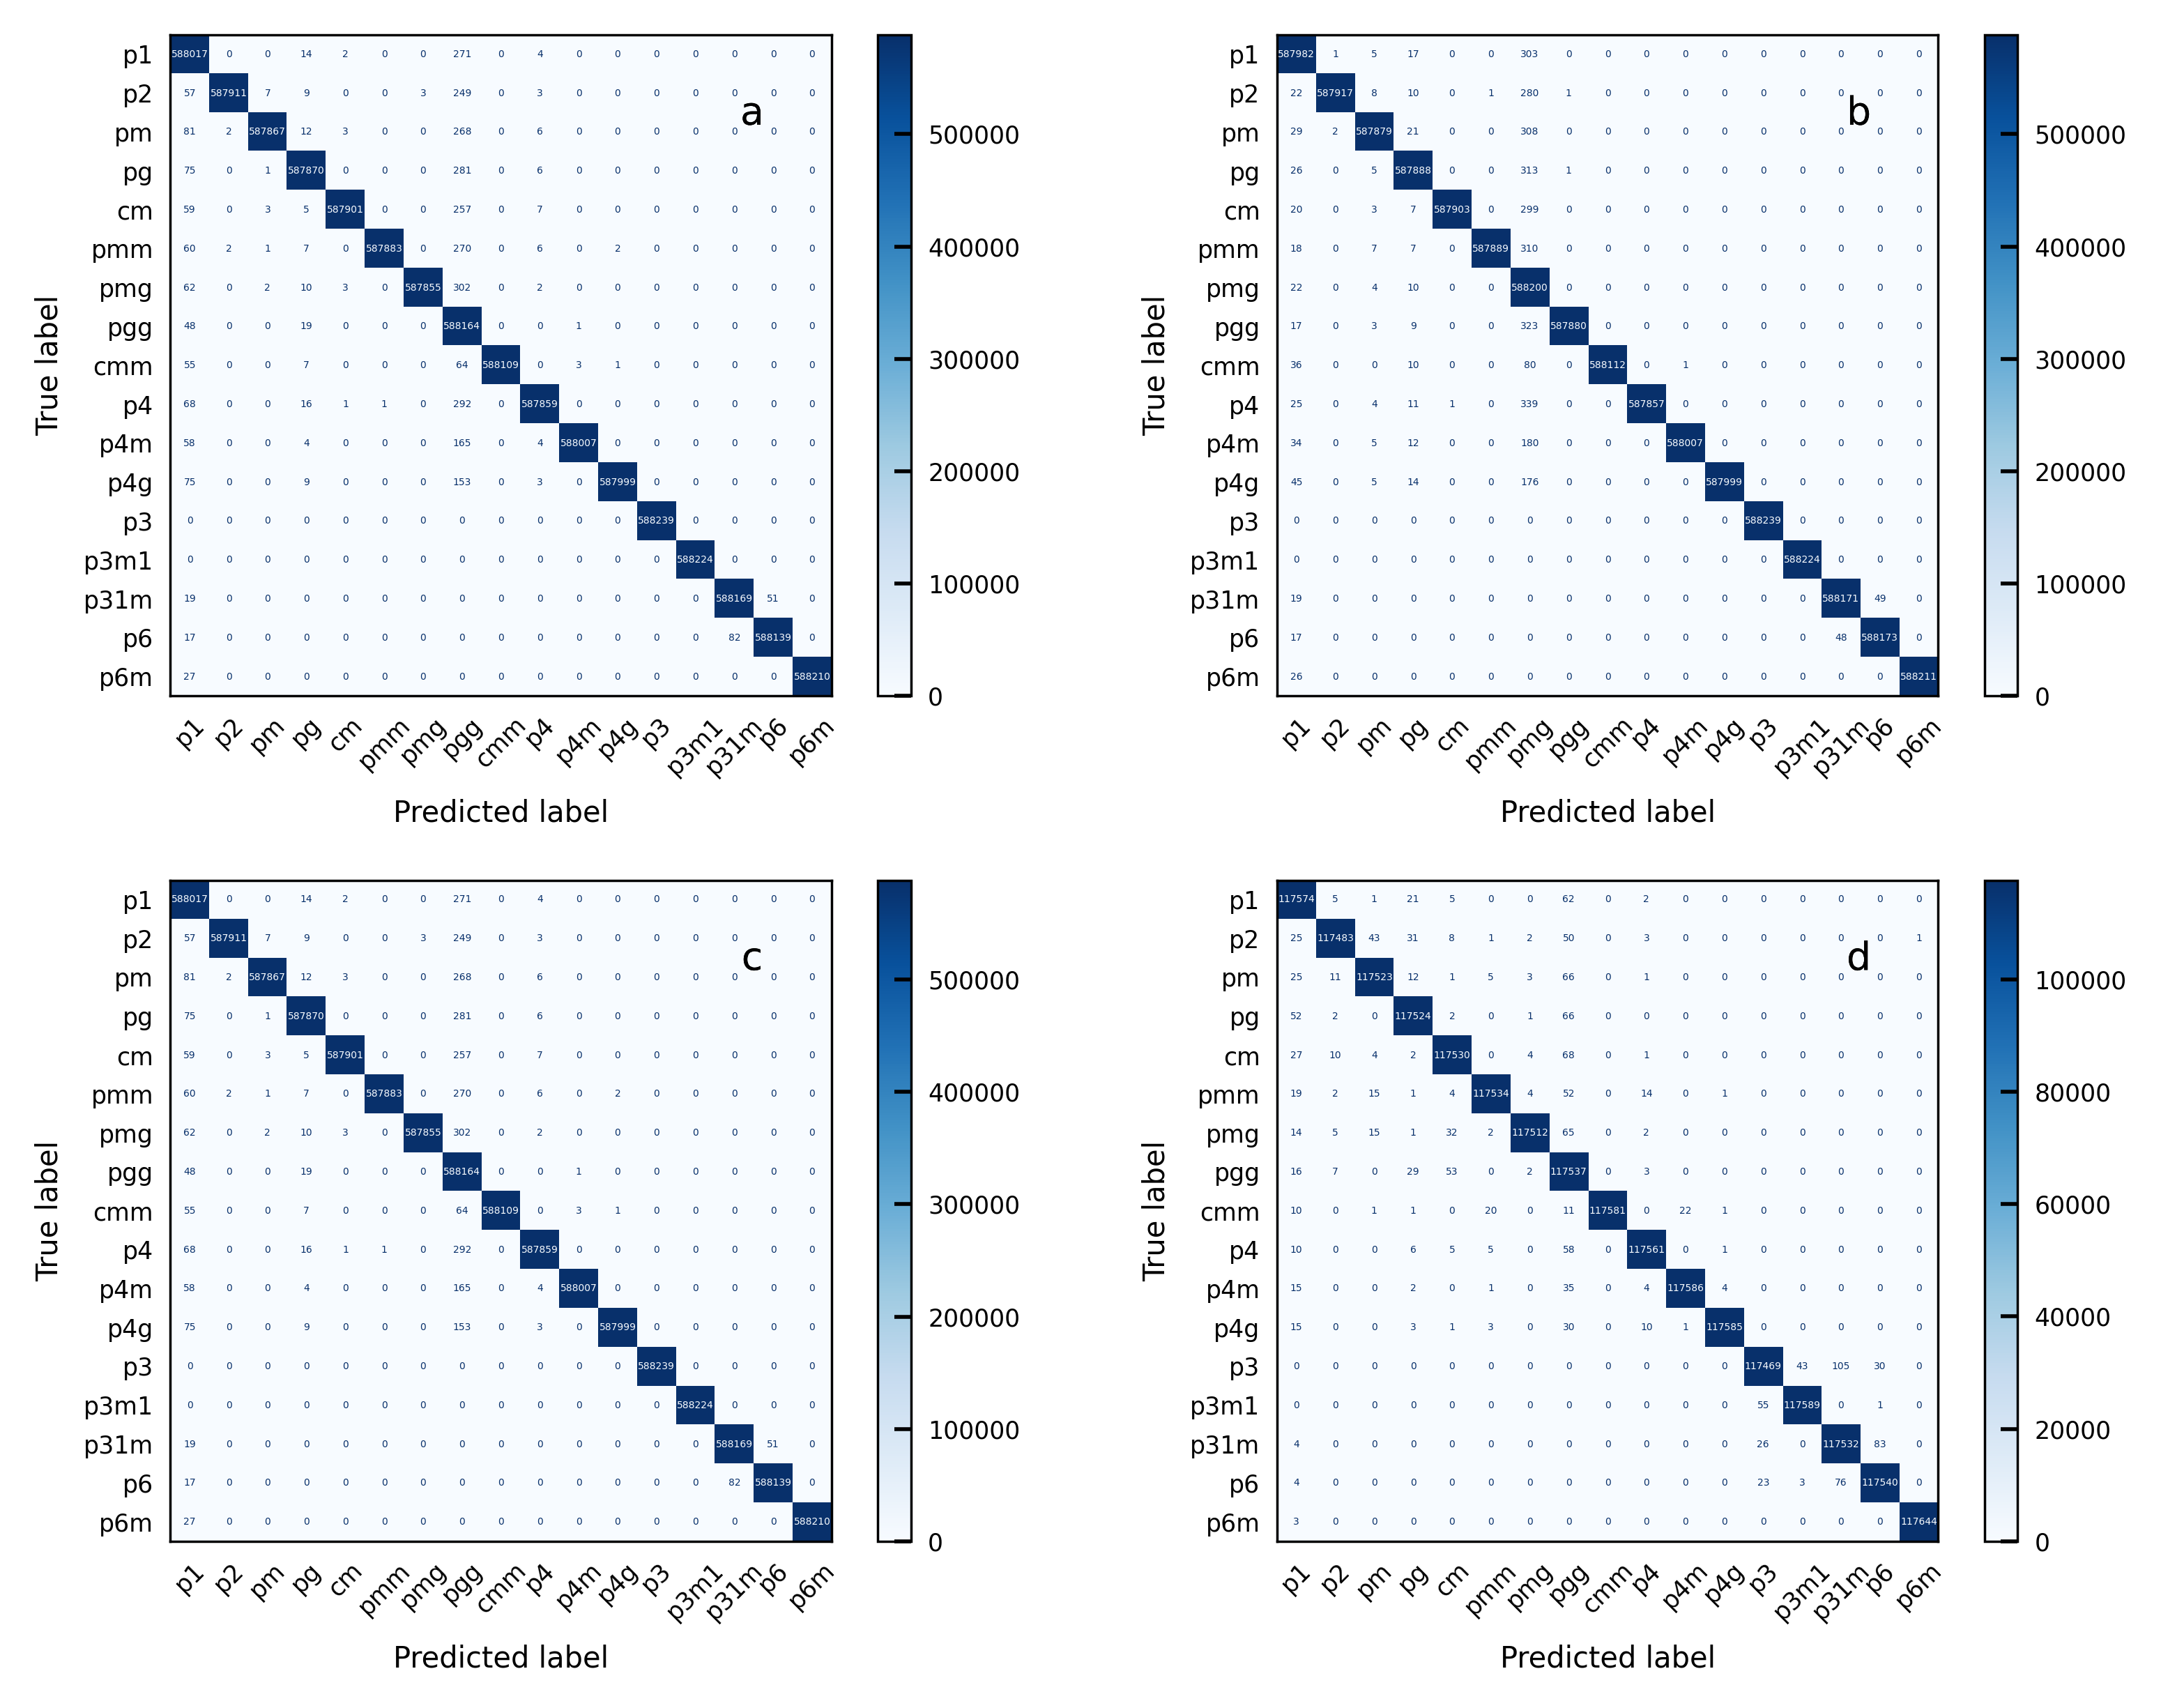

In [ ]:
# print(sorted_files)
NAME = 'Summary_cm-' + '-'.join(os.path.basename(sorted_files[0]).split('-')[:2])
print(NAME)

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, file) in enumerate(zip(axes.flatten(), sorted_files)):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=2)
plt.tight_layout()
plt.savefig(f'../../../figures/Benchmark/ResNet50/{NAME}.png')
plt.savefig(f'../../../figures/Benchmark/ResNet50/{NAME}.svg')
plt.show()